# Phase 1 — Data Understanding

[`walkthrough/phase1.md`](../walkthrough/phase1.md)

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid")

DATA_PATH = "../dataset/data.csv"
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (20000, 27)


,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,Utilities,Healthcare,Education,Miscellaneous,Desired_Savings_Percentage,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,1651.801726,1536.184255,2911.792231,1546.914539,0.000000,831.525120,13.890948,6200.537192,11265.627707,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,649.378103,1050.241738,1626.143346,1137.351325,1551.723167,564.235007,7.160376,1923.176434,9676.818733,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,1513.814376,1723.306926,3368.457108,2178.515847,3160.026299,628.371220,13.997808,7050.360422,13891.450624,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,5040.249158,2858.194240,6128.550387,4571.118217,0.000000,2526.055712,16.455440,16694.965136,31617.953615,1875.932770,762.020789,1241.017448,320.190594,1389.815033,193.502754,0.000000,296.041183
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,692.827225,660.186852,1092.689024,1169.095816,1445.215694,515.510300,7.533982,1874.099434,6265.700532,788.953124,68.160766,61.712505,187.173750,194.117130,47.294591,67.388120,96.557076


## Column types and cardinality

In [2]:
dtypes_table = df.dtypes.rename("dtype").to_frame()
dtypes_table["n_unique"] = df.nunique()
dtypes_table

,dtype,n_unique
Income,float64,20000
Age,int64,47
Dependents,int64,5
Occupation,str,4
City_Tier,str,3
Rent,float64,20000
Loan_Repayment,float64,7970
Insurance,float64,20000
Groceries,float64,20000
Transport,float64,20000


## Distributions

In [3]:
money_cols = [
    "Income",
    "Rent",
    "Loan_Repayment",
    "Insurance",
    "Groceries",
    "Transport",
    "Eating_Out",
    "Entertainment",
    "Utilities",
    "Healthcare",
    "Education",
    "Miscellaneous",
    "Desired_Savings",
    "Disposable_Income",
]
desc = df[money_cols].describe().T
desc["skew"] = df[money_cols].skew()
desc

,count,mean,std,min,25%,50%,75%,max,skew
Income,20000.0,41585.496104,40014.540538,1301.187333,17604.875957,30185.383480,51765.446460,1.079728e+06,4.232803
Rent,20000.0,9115.494629,9254.228188,235.365692,3649.422246,6402.751824,11263.940492,2.159457e+05,4.150531
Loan_Repayment,20000.0,2049.800292,4281.789941,0.000000,0.000000,0.000000,2627.142320,1.230807e+05,5.099544
Insurance,20000.0,1455.028761,1492.938435,30.002012,580.204749,1017.124681,1787.160895,3.873493e+04,4.513667
Groceries,20000.0,5205.667493,5035.953689,154.078240,2165.426419,3741.091535,6470.892718,1.198169e+05,3.960422
Transport,20000.0,2704.466685,2666.345648,81.228584,1124.578012,1933.845509,3360.597508,8.186150e+04,4.736227
Eating_Out,20000.0,1461.856982,1481.660811,39.437523,581.011801,1029.109726,1807.075251,3.440610e+04,3.887579
Entertainment,20000.0,1448.853658,1489.019270,45.421469,581.632906,1020.198376,1790.104082,3.866737e+04,4.665013
Utilities,20000.0,2504.976953,2522.981880,75.429414,1017.670366,1766.474869,3103.723308,5.372544e+04,4.347142
Healthcare,20000.0,1663.081794,1628.163024,53.500761,684.364440,1189.203827,2057.082277,3.600153e+04,3.883214


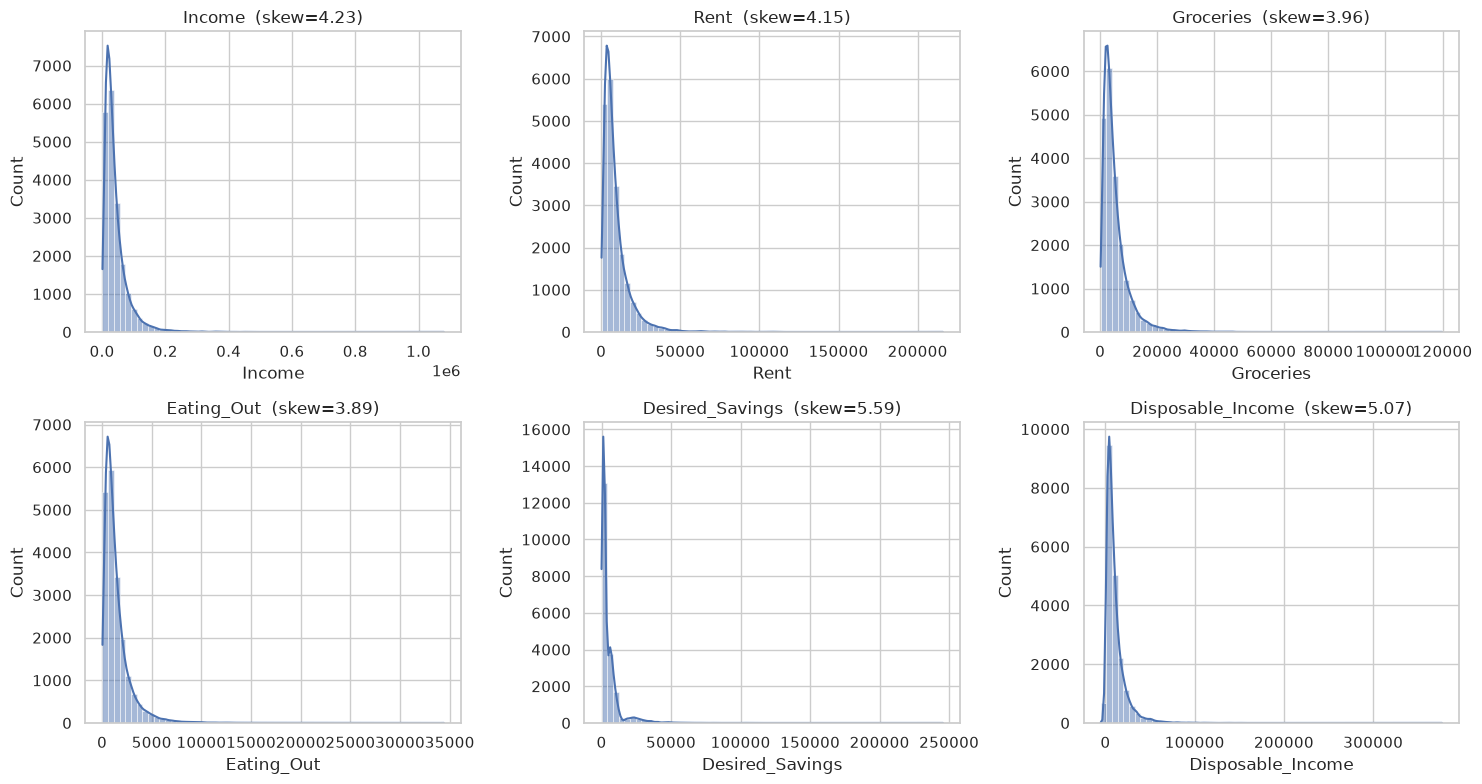

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(
    axes.ravel(),
    [
        "Income",
        "Rent",
        "Groceries",
        "Eating_Out",
        "Desired_Savings",
        "Disposable_Income",
    ],
):
    sns.histplot(df[col], bins=60, ax=ax, kde=True)
    ax.set_title(f"{col}  (skew={df[col].skew():.2f})")
fig.tight_layout()
plt.show()

In [5]:
def iqr_outlier_count(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((s < lo) | (s > hi)).sum())


outlier_counts = {c: iqr_outlier_count(df[c]) for c in money_cols}
pd.Series(outlier_counts, name="n_outliers_iqr_1.5x").sort_values(ascending=False)

Loan_Repayment       1880
Insurance            1375
Miscellaneous        1348
Disposable_Income    1331
Eating_Out           1325
Entertainment        1324
Rent                 1320
Desired_Savings      1303
Healthcare           1294
Utilities            1291
Transport            1261
Income               1254
Groceries            1227
Education            1159
Name: n_outliers_iqr_1.5x, dtype: int64

In [6]:
expense_cols = [
    "Rent",
    "Loan_Repayment",
    "Insurance",
    "Groceries",
    "Transport",
    "Eating_Out",
    "Entertainment",
    "Utilities",
    "Healthcare",
    "Education",
    "Miscellaneous",
]
df["Total_Expenses"] = df[expense_cols].sum(axis=1)

implausible_mask = df["Total_Expenses"] > df["Income"]
n_implausible = int(implausible_mask.sum())
print(
    f"Rows where total expenses exceed income: {n_implausible} ({n_implausible / len(df):.2%})"
)
df.loc[implausible_mask, ["Income", "Total_Expenses"] + expense_cols].head()

Rows where total expenses exceed income: 112 (0.56%)


,Income,Total_Expenses,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,Utilities,Healthcare,Education,Miscellaneous
75,57900.115834,58749.768804,17370.034750,11444.465837,2096.455402,7942.672949,3662.132761,2816.307979,2288.619858,4065.145450,2260.957432,3600.365467,1202.610918
89,45232.295239,45754.652159,13569.688572,7866.640734,1965.577171,6066.899047,2926.367477,2231.073946,1125.548611,3237.048055,1634.428725,3858.715109,1272.664711
99,24866.653150,25458.506090,7459.995945,4433.243478,1031.191867,3600.207432,1877.647130,1225.300322,689.283973,1649.509180,1020.504740,2083.610546,388.011478
130,8676.920085,8703.779179,2603.076026,1185.411490,351.509239,1295.196949,573.597794,361.432565,320.527699,680.415064,406.545318,829.883783,96.183253
250,10940.704791,10966.509422,3282.211437,2180.852234,365.963051,1532.695458,641.846058,376.432863,400.270920,649.541381,337.109167,1085.881490,113.705363


## Missing values and duplicate rows

In [7]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:", missing.to_dict() if len(missing) else "none")
print("Total missing cells:", int(df.isnull().sum().sum()))
print("Duplicate rows (all columns):", int(df.duplicated().sum()))

Columns with missing values: none
Total missing cells: 0
Duplicate rows (all columns): 0


## Correlation: income vs. expenses

In [8]:
corr_full = df[["Income"] + expense_cols].corr()
corr_full["Income"].drop("Income").sort_values(ascending=False)

Groceries         0.985717
Transport         0.981955
Healthcare        0.978838
Utilities         0.964414
Insurance         0.944395
Entertainment     0.943594
Eating_Out        0.939673
Rent              0.939370
Miscellaneous     0.919519
Education         0.794558
Loan_Repayment    0.447598
Name: Income, dtype: float64

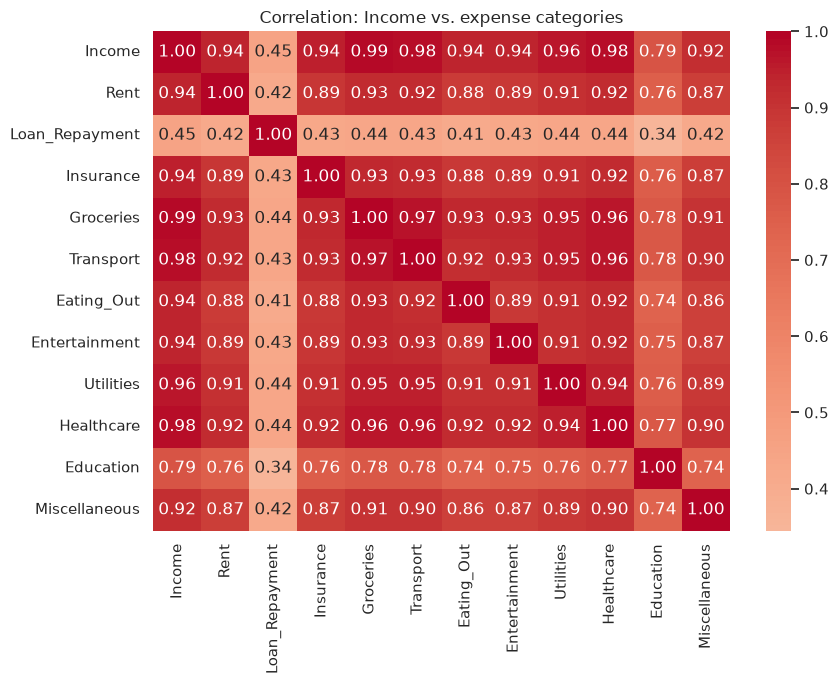

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_full, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation: Income vs. expense categories")
fig.tight_layout()
plt.show()

In [10]:
import itertools

expense_corr = df[expense_cols].corr()
pairs = sorted(
    (
        (a, b, expense_corr.loc[a, b])
        for a, b in itertools.combinations(expense_cols, 2)
    ),
    key=lambda t: -abs(t[2]),
)
pd.DataFrame(pairs[:8], columns=["feature_a", "feature_b", "correlation"])

,feature_a,feature_b,correlation
0,Groceries,Transport,0.967789
1,Groceries,Healthcare,0.964956
2,Transport,Healthcare,0.960117
3,Groceries,Utilities,0.950489
4,Transport,Utilities,0.945710
5,Utilities,Healthcare,0.944568
6,Groceries,Entertainment,0.931417
7,Groceries,Eating_Out,0.929536


## Leakage check

In [11]:
df["Disposable_Income_recalculated"] = df["Income"] - df["Total_Expenses"]
max_abs_diff = (
    (df["Disposable_Income_recalculated"] - df["Disposable_Income"]).abs().max()
)
print(
    f"Max |Income - sum(expenses) - Disposable_Income| across all rows: {max_abs_diff:.2e}"
)

Max |Income - sum(expenses) - Disposable_Income| across all rows: 8.73e-11


In [12]:
df["Goal_Met"] = (df["Disposable_Income"] >= df["Desired_Savings"]).astype(int)

trivial_rule = (df["Disposable_Income"] >= df["Desired_Savings"]).astype(int)
print(
    "Trivial-rule accuracy vs Goal_Met (using only leakage columns):",
    (trivial_rule == df["Goal_Met"]).mean(),
)

leakage_cols = ["Disposable_Income", "Desired_Savings", "Desired_Savings_Percentage"]
print("Columns excluded from the feature set due to leakage:", leakage_cols)

Trivial-rule accuracy vs Goal_Met (using only leakage columns): 1.0
Columns excluded from the feature set due to leakage: ['Disposable_Income', 'Desired_Savings', 'Desired_Savings_Percentage']


## Class balance of `Goal_Met`

In [13]:
balance = (
    df["Goal_Met"].value_counts().rename({0: "Goal not met (0)", 1: "Goal met (1)"})
)
balance_pct = (
    df["Goal_Met"]
    .value_counts(normalize=True)
    .rename({0: "Goal not met (0)", 1: "Goal met (1)"})
)
pd.DataFrame({"count": balance, "proportion": balance_pct.round(4)})

,count,proportion
Goal_Met,,
Goal met (1),19888,0.9944
Goal not met (0),112,0.0056


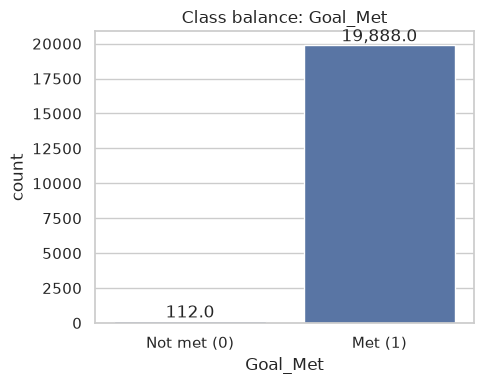

In [14]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x="Goal_Met", data=df, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Not met (0)", "Met (1)"])
ax.set_title("Class balance: Goal_Met")
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():,}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
    )
fig.tight_layout()
plt.show()